In [43]:
import numpy as np
from scipy.sparse import diags

In [125]:
#h = 3
L = 2
c = 1
d = 2.71**2
n = 3

def K_matrix(length,h_n,i=None, h_const=None):
    h = np.zeros(h_n)
    if i is None: 
        h[:] = length/(h_n-1)
        i = 0
    elif h_const != None: 
        h[:] = h_const
        i = 0
    else: h = h_const
    return np.array([[1/h[i]+h[i]/3, -1/h[i]+h[i]/6],[-1/h[i]+h[i]/6, 1/h[i]+h[i]/3]]).round(3)
h_cons = np.array([1,1])
K = K_matrix(L,n,h_const=1)
print("K = ", K)

A = np.zeros((n,n))
# computing the A matrix through the diagonal
d0 = np.trace(K)
du = K[0, 1]
dl = K[1, 0]

A_sparse = diags(
    diagonals=[dl*np.ones(n-1), d0*np.ones(n), du*np.ones(n-1)],
    offsets=[-1, 0, 1],
    format="csr"
)
A = A_sparse.toarray()
# this is the vector for values of which we want to solve
b = np.zeros(n-2)
b[0] = -K[1,0]*c
b[-1] = -K[0,1]*d
A = A[1:-1,1:-1]
u_res = np.linalg.solve(A,b)
u_res


K =  [[ 1.333 -0.833]
 [-0.833  1.333]]


array([2.29468691])

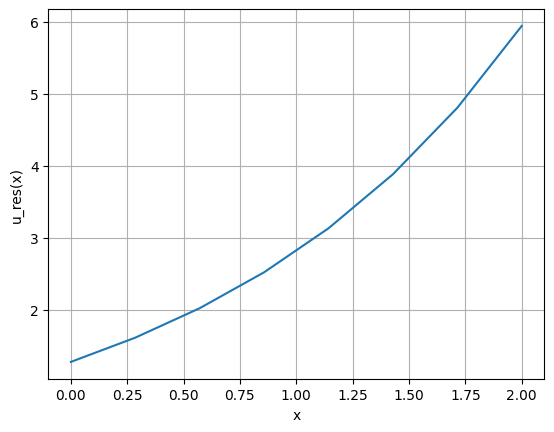

In [113]:
x = np.linspace(0,L,n-2)

plt.plot(x,u_res)
plt.ylabel('u_res(x)')
plt.xlabel('x')
plt.grid()
plt.show()

### Expanding system to M = 6 for visual interpretation

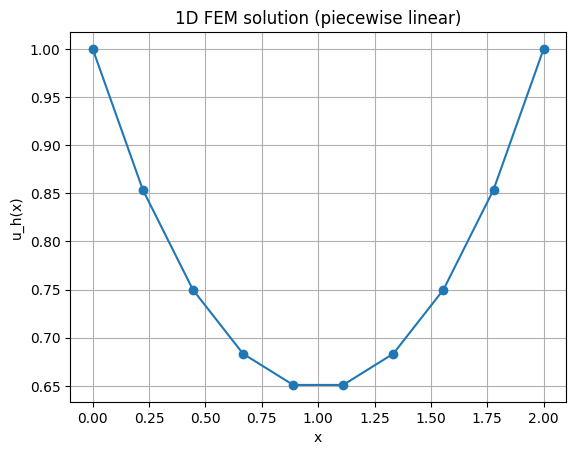

array([0.85370305, 0.74991413, 0.68346533, 0.651048  , 0.651048  ,
       0.68346533, 0.74991413, 0.85370305])

In [86]:
import numpy as np
import matplotlib.pyplot as plt

L = 2.0
c = 1.0
d = 1#2.71**2
n = 10

# consistent mesh size for n nodes on [0, L]
h = L / (n - 1)
x = np.linspace(0, L, n)

# element matrix for -u'' + u = 0 (equivalent to u'' - u = 0)
K = np.array([[1/h + h/3, -1/h + h/6],
              [-1/h + h/6, 1/h + h/3]])

# assemble global tridiagonal matrix (dense for simplicity)
A = np.zeros((n, n))
diag = np.trace(K)
off  = K[0, 1]  # same as K[1,0]

np.fill_diagonal(A, diag)
A[np.arange(n-1), np.arange(n-1)+1] = off
A[np.arange(n-1)+1, np.arange(n-1)] = off

# Dirichlet BC elimination: solve for interior nodes only
A_int = A[1:-1, 1:-1]
b = np.zeros(n-2)
b[0]  = -A[1, 0]   * c   # contribution of left boundary u0=c
b[-1] = -A[-2, -1] * d   # contribution of right boundary u_{n-1}=d

u_int = np.linalg.solve(A_int, b)

# reconstruct full nodal vector (includes boundary values)
u = np.r_[c, u_int, d]

# Plot nodal solution (piecewise linear between nodes)
plt.figure()
plt.plot(x, u, marker="o")
plt.xlabel("x")
plt.ylabel("u_h(x)")
plt.title("1D FEM solution (piecewise linear)")
plt.grid(True)
plt.show()

u_int
